---
# 🐱 CatBoost — Part 2: Regression

## Dataset: California Housing
**Goal:** Predict the **median house value** for California districts

| Property     | Detail                                                   |
|-------------|----------------------------------------------------------|
| Source      | Sklearn built-in dataset (from 1990 US Census)           |
| Samples     | 20,640 rows                                              |
| Features    | 8 numeric features (geographic + demographic)            |
| Target      | `MedHouseVal` — Median house value (in $100,000 units)   |

### Why this is suitable for CatBoost Regression:
- Tabular numeric data where tree ensembles excel
- Non-linear relationships (e.g., location, income clusters)
- CatBoost Regressor is as straightforward as the classifier

In [ ]:
# ── Imports ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from catboost import CatBoostRegressor

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Optional comparison / interpretation libraries
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


In [2]:
from catboost import CatBoostRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
housing = fetch_california_housing(as_frame=True)
df_reg = housing.frame.copy()

print("Shape:", df_reg.shape)
print("\nFeature descriptions:")
for name, desc in zip(housing.feature_names, housing.DESCR.split("\n")[6:14]):
    print(f"  {name:15}: {desc.strip()}")
print(f"\nTarget: MedHouseVal (median house value in $100k)")
df_reg.head()


# ============================================================
# SECTION 1 — EDA (Regression)
# ============================================================

Shape: (20640, 9)

Feature descriptions:
  MedInc         : 
  HouseAge       : :Number of Instances: 20640
  AveRooms       : 
  AveBedrms      : :Number of Attributes: 8 numeric, predictive attributes and the target
  Population     : 
  AveOccup       : :Attribute Information:
  Latitude       : - MedInc        median income in block group
  Longitude      : - HouseAge      median house age in block group

Target: MedHouseVal (median house value in $100k)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 1. EDA — California Housing

In [3]:
# ── Missing values ───────────────────────────────────────────
print("=== Missing Values ===")
print(df_reg.isnull().sum())

=== Missing Values ===
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [4]:
# ── Data types ───────────────────────────────────────────────
print("\n=== Data Types ===")
print(df_reg.dtypes)
print(f"\nStatistical Summary:")
df_reg.describe().round(2)


=== Data Types ===
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


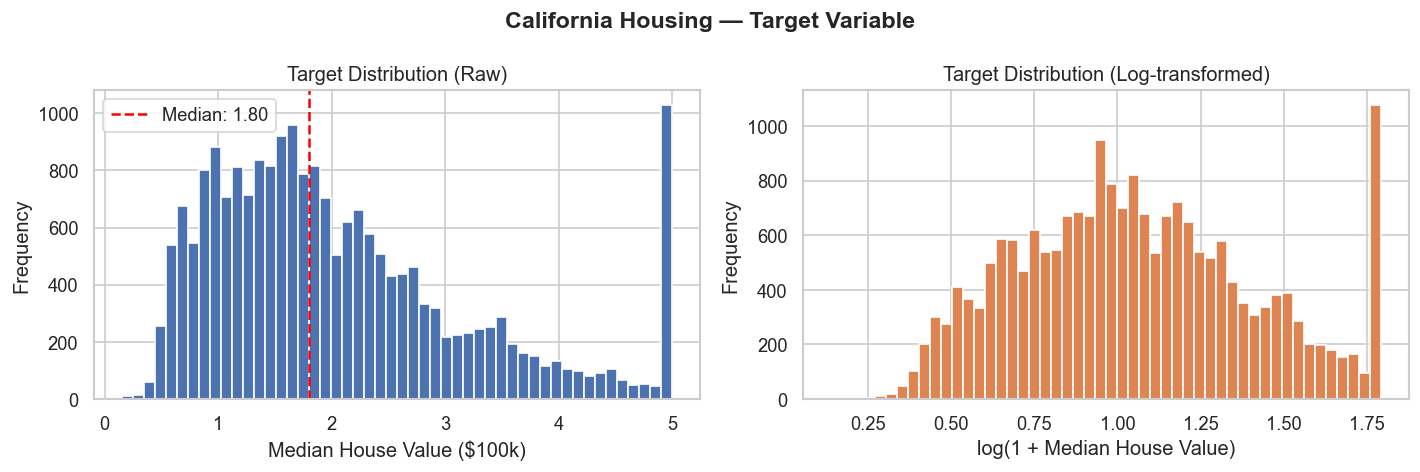


Observation:
  The target is right-skewed with a hard cap at 5.0 ($500,000) — common in
  census data. The log transform shows a more symmetric distribution.
  CatBoost trees are scale-invariant, so we will train on the raw values,
  but note the ceiling effect in high-value predictions.



In [5]:
# ── Target distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_reg["MedHouseVal"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Median House Value ($100k)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Target Distribution (Raw)")
axes[0].axvline(df_reg["MedHouseVal"].median(), color="red",
                 linestyle="--", label=f"Median: {df_reg['MedHouseVal'].median():.2f}")
axes[0].legend()

axes[1].hist(np.log1p(df_reg["MedHouseVal"]), bins=50, color="#DD8452", edgecolor="white")
axes[1].set_xlabel("log(1 + Median House Value)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Target Distribution (Log-transformed)")

plt.suptitle("California Housing — Target Variable", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("""
Observation:
  The target is right-skewed with a hard cap at 5.0 ($500,000) — common in
  census data. The log transform shows a more symmetric distribution.
  CatBoost trees are scale-invariant, so we will train on the raw values,
  but note the ceiling effect in high-value predictions.
""")

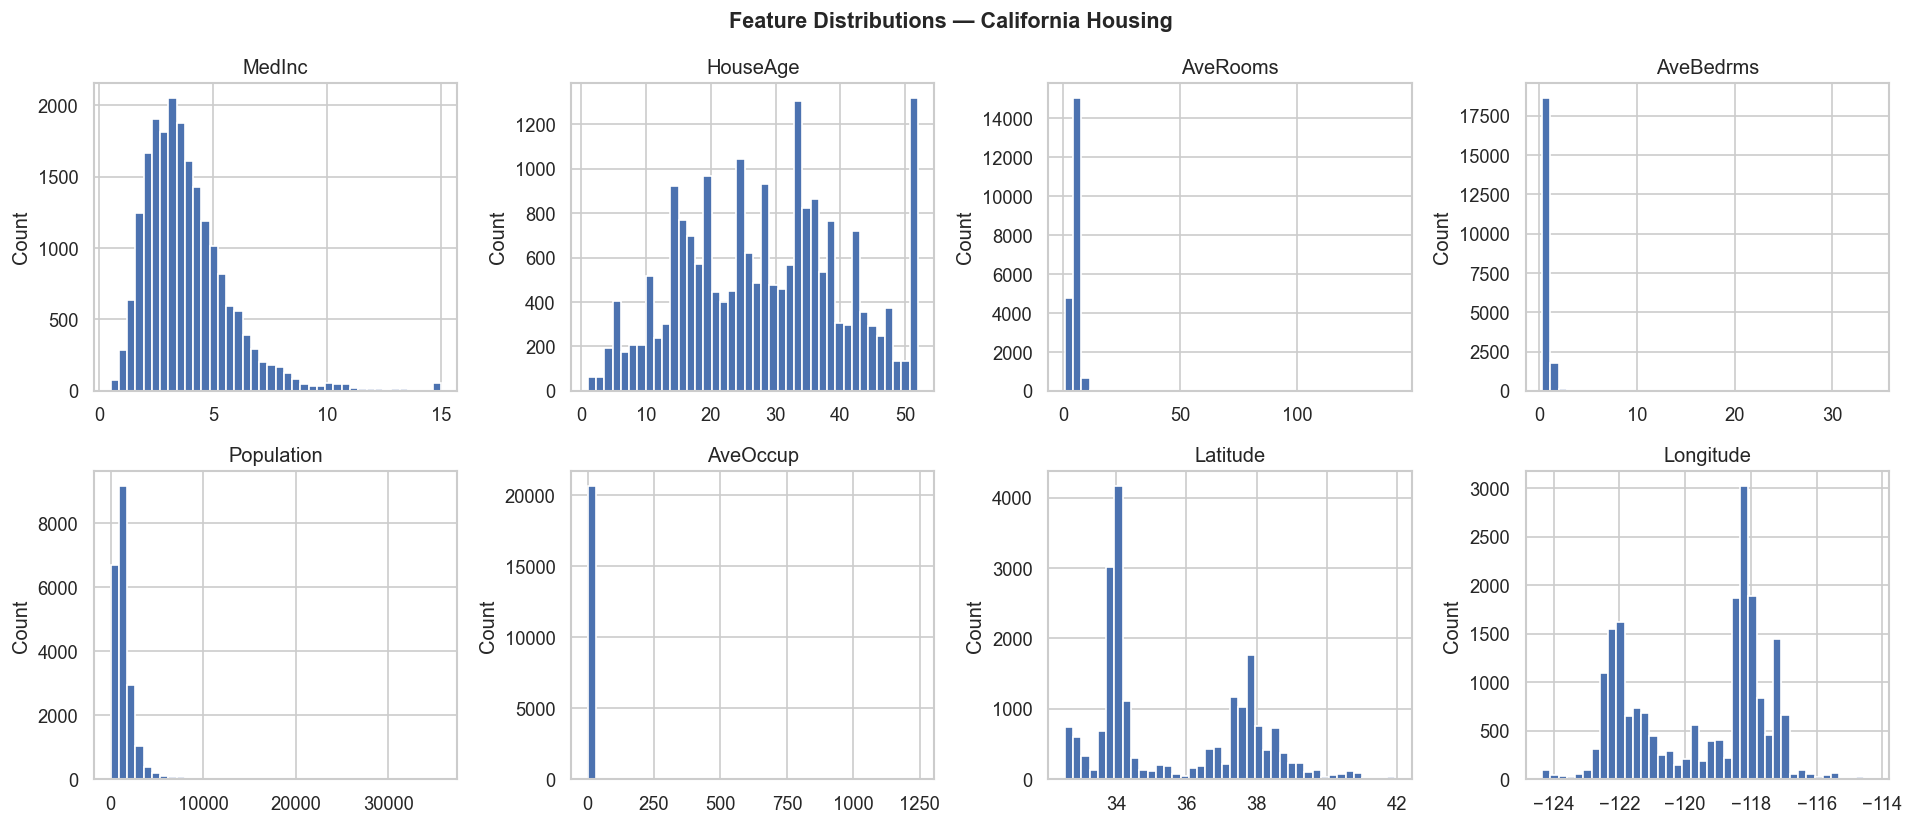

In [6]:
# ── Feature distributions ────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), housing.feature_names):
    df_reg[col].hist(ax=ax, bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel("Count")
plt.suptitle("Feature Distributions — California Housing", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

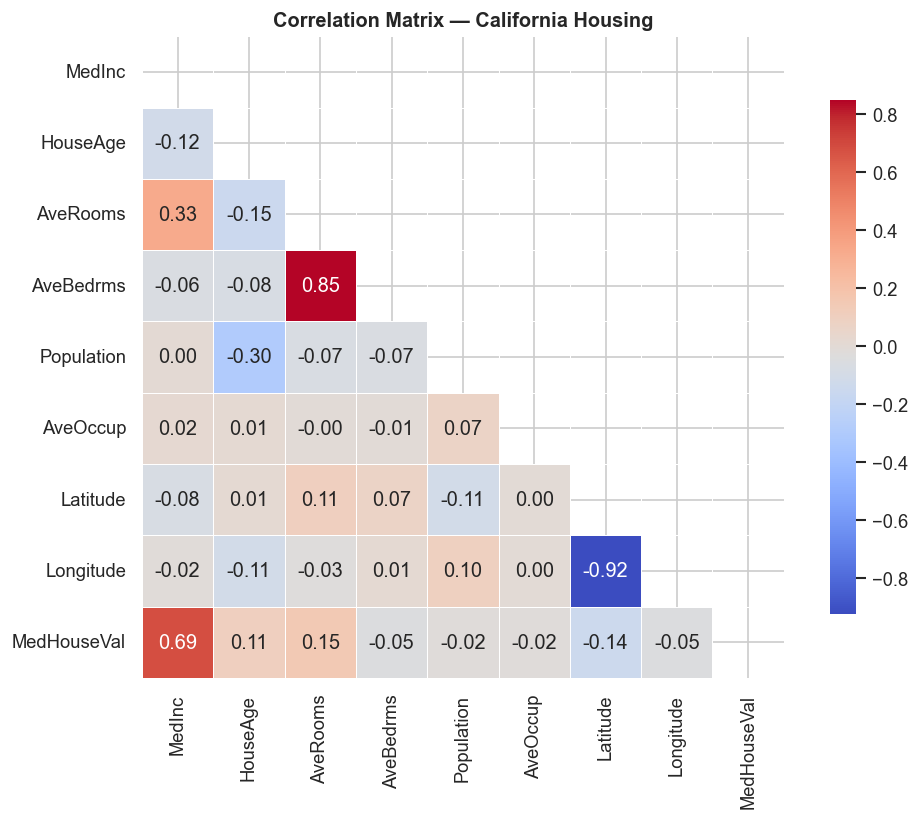


Key correlations with target (MedHouseVal):
  - MedInc (Median Income): Strong positive correlation (~0.69) — 
    wealthier districts have higher house values.
  - Latitude / Longitude: Moderate correlation — location matters.
  - AveRooms: Weak positive — more rooms, slightly higher value.



In [7]:
# ── Correlation heatmap ──────────────────────────────────────
plt.figure(figsize=(9, 7))
corr_reg = df_reg.corr()
mask = np.triu(np.ones_like(corr_reg, dtype=bool))
sns.heatmap(corr_reg, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix — California Housing", fontweight="bold")
plt.tight_layout()
plt.show()

print("""
Key correlations with target (MedHouseVal):
  - MedInc (Median Income): Strong positive correlation (~0.69) — 
    wealthier districts have higher house values.
  - Latitude / Longitude: Moderate correlation — location matters.
  - AveRooms: Weak positive — more rooms, slightly higher value.
""")

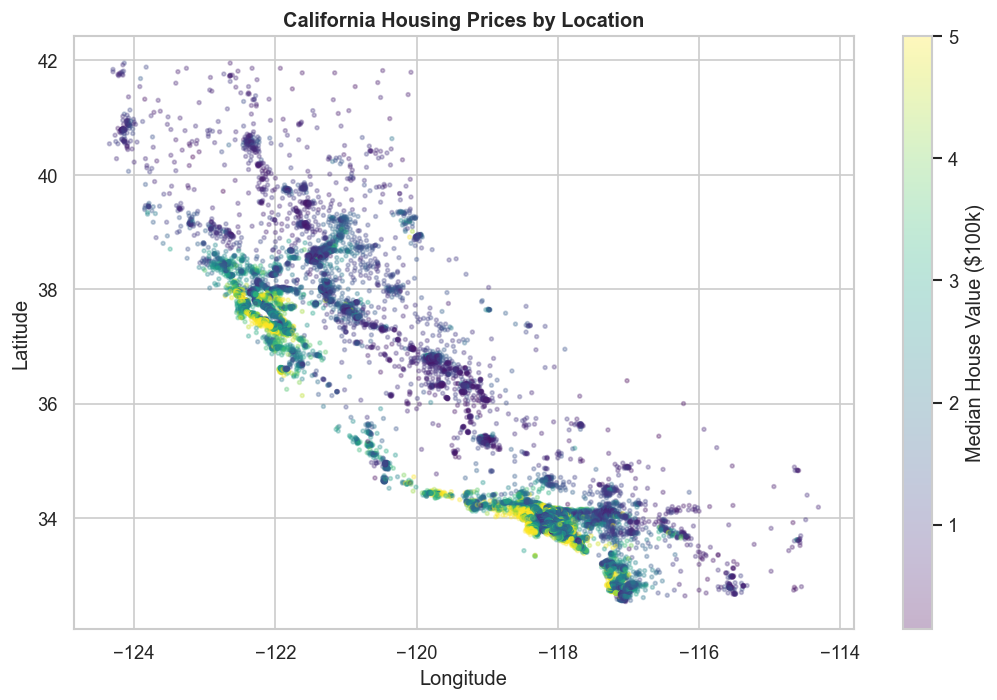

Expensive areas (yellow) cluster around Los Angeles and the Bay Area.


In [8]:
# ── Geographic scatter ───────────────────────────────────────
plt.figure(figsize=(9, 6))
sc = plt.scatter(df_reg["Longitude"], df_reg["Latitude"],
                 c=df_reg["MedHouseVal"], cmap="viridis",
                 alpha=0.3, s=5)
plt.colorbar(sc, label="Median House Value ($100k)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Prices by Location", fontweight="bold")
plt.tight_layout()
plt.show()

print("Expensive areas (yellow) cluster around Los Angeles and the Bay Area.")


# ============================================================
# SECTION 2 — Preprocessing (Regression)
# ============================================================

## 2. Data Preprocessing

Steps:
1. No missing values → nothing to impute
2. No categorical features in this dataset
3. Feature engineering: add Rooms-per-Household
4. Train/Test split (80/20)

> **Scaling**: Not required — CatBoost is tree-based and invariant to feature scale.

In [9]:
# ── Feature engineering ──────────────────────────────────────
df_reg["RoomsPerHousehold"]    = df_reg["AveRooms"]    / df_reg["HouseAge"].clip(lower=1)
df_reg["BedroomsPerRoom"]      = df_reg["AveBedrms"]   / df_reg["AveRooms"].clip(lower=1)
# `Households` is not a native column in sklearn's California Housing dataset.
# Approximate it from Population and AveOccup, then compute PopulationPerHousehold.
df_reg["Households"] = df_reg["Population"] / df_reg["AveOccup"].clip(lower=1e-6)
df_reg["PopulationPerHousehold"] = df_reg["Population"] / df_reg["Households"].clip(lower=1)

print("New features added:")
print(df_reg[["RoomsPerHousehold", "BedroomsPerRoom", "PopulationPerHousehold"]].describe().round(3))

# ── Define X and y ───────────────────────────────────────────
X_reg = df_reg.drop(columns=["MedHouseVal"])
y_reg = df_reg["MedHouseVal"]

# ── Train/Test split ─────────────────────────────────────────
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"\nTrain: {X_train_r.shape[0]} rows | Test: {X_test_r.shape[0]} rows")


# ============================================================
# SECTION 3 — Model Training (Regression)
# ============================================================

New features added:
       RoomsPerHousehold  BedroomsPerRoom  PopulationPerHousehold
count          20640.000        20640.000               20640.000
mean               0.282            0.213                   3.071
std                0.390            0.058                  10.386
min                0.018            0.100                   0.692
25%                0.128            0.175                   2.430
50%                0.180            0.203                   2.818
75%                0.302            0.240                   3.282
max               20.125            1.000                1243.333

Train: 16512 rows | Test: 4128 rows


## 3. Model Training

Two CatBoost Regressors:
- **Default**: out-of-the-box settings
- **Tuned**: after RandomizedSearchCV

In [10]:
# ── 3.1 Default Regressor ────────────────────────────────────
model_reg_default = CatBoostRegressor(
    iterations=500,
    random_seed=42,
    verbose=100
)
model_reg_default.fit(
    X_train_r, y_train_r,
    eval_set=(X_test_r, y_test_r),
    early_stopping_rounds=50
)

Learning rate set to 0.120703
0:	learn: 1.0800634	test: 1.0704467	best: 1.0704467 (0)	total: 154ms	remaining: 1m 17s
100:	learn: 0.4720455	test: 0.5049061	best: 0.5049061 (100)	total: 616ms	remaining: 2.43s
200:	learn: 0.4170620	test: 0.4708783	best: 0.4708783 (200)	total: 1.03s	remaining: 1.53s
300:	learn: 0.3868593	test: 0.4593922	best: 0.4593922 (300)	total: 1.44s	remaining: 950ms
400:	learn: 0.3633003	test: 0.4528774	best: 0.4526947 (397)	total: 1.86s	remaining: 458ms
499:	learn: 0.3439368	test: 0.4472602	best: 0.4470387 (497)	total: 2.27s	remaining: 0us

bestTest = 0.4470386881
bestIteration = 497

Shrink model to first 498 iterations.


In [11]:
# ── 3.2 Quick eval of default model ─────────────────────────
def reg_metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"\n=== {name} ===")
    print(f"  MAE  : {mae:.4f}  (average error in $100k)")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}  (typical error in $100k)")
    print(f"  R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)")
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

y_pred_reg_def = model_reg_default.predict(X_test_r)
default_scores = reg_metrics("Default Regressor", y_test_r, y_pred_reg_def)


# ============================================================
# SECTION 4 — Hyperparameter Tuning (Regression)
# ============================================================


=== Default Regressor ===
  MAE  : 0.2953  (average error in $100k)
  MSE  : 0.1998
  RMSE : 0.4470  (typical error in $100k)
  R²   : 0.8475  (84.7% variance explained)


In [12]:
param_dist_reg = {
    "iterations":    [300, 500, 700, 1000],
    "depth":         [4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.15],
    "l2_leaf_reg":   [1, 3, 5, 7, 10],
    "border_count":  [32, 64, 128],
}

base_reg = CatBoostRegressor(random_seed=42, verbose=0)

random_search_reg = RandomizedSearchCV(
    estimator=base_reg,
    param_distributions=param_dist_reg,
    n_iter=10,
    scoring="neg_root_mean_squared_error",   # minimise RMSE
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_reg.fit(X_train_r, y_train_r)
print("\nBest Parameters:", random_search_reg.best_params_)
print(f"Best CV RMSE: {-random_search_reg.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters: {'learning_rate': 0.1, 'l2_leaf_reg': 10, 'iterations': 700, 'depth': 8, 'border_count': 128}
Best CV RMSE: 0.4509


In [13]:
# ── Train tuned regressor ────────────────────────────────────
model_reg_tuned = CatBoostRegressor(
    **random_search_reg.best_params_,
    random_seed=42,
    verbose=100
)
model_reg_tuned.fit(
    X_train_r, y_train_r,
    eval_set=(X_test_r, y_test_r),
    early_stopping_rounds=50
)

y_pred_reg_tuned = model_reg_tuned.predict(X_test_r)
tuned_scores = reg_metrics("Tuned Regressor", y_test_r, y_pred_reg_tuned)


# ============================================================
# SECTION 5 — Evaluation Visualizations (Regression)
# ============================================================

0:	learn: 1.0918664	test: 1.0825637	best: 1.0825637 (0)	total: 69.6ms	remaining: 48.6s
100:	learn: 0.4671213	test: 0.5048836	best: 0.5048836 (100)	total: 1.03s	remaining: 6.1s
200:	learn: 0.4122433	test: 0.4746523	best: 0.4746523 (200)	total: 1.85s	remaining: 4.6s
300:	learn: 0.3784469	test: 0.4633257	best: 0.4633257 (300)	total: 2.59s	remaining: 3.44s
400:	learn: 0.3532488	test: 0.4560240	best: 0.4560240 (400)	total: 3.33s	remaining: 2.49s
500:	learn: 0.3316291	test: 0.4500434	best: 0.4500434 (500)	total: 4.12s	remaining: 1.63s
600:	learn: 0.3140031	test: 0.4468076	best: 0.4468076 (600)	total: 4.86s	remaining: 801ms
699:	learn: 0.2982627	test: 0.4441778	best: 0.4441778 (699)	total: 5.6s	remaining: 0us

bestTest = 0.4441778493
bestIteration = 699


=== Tuned Regressor ===
  MAE  : 0.2908  (average error in $100k)
  MSE  : 0.1973
  RMSE : 0.4442  (typical error in $100k)
  R²   : 0.8494  (84.9% variance explained)


In [14]:
# ── Metrics comparison table ────────────────────────────────
metrics_reg = pd.DataFrame({
    "Metric":  ["MAE", "MSE", "RMSE", "R²"],
    "Default": [default_scores["MAE"], default_scores["MSE"],
                default_scores["RMSE"], default_scores["R2"]],
    "Tuned":   [tuned_scores["MAE"], tuned_scores["MSE"],
                tuned_scores["RMSE"], tuned_scores["R2"]]
}).round(4)

print(metrics_reg.to_string(index=False))

print("""
Interpretation:
  - MAE  : On average the model's price prediction is off by MAE × $100k.
  - RMSE : Similar to MAE but penalises large errors more heavily.
           Lower RMSE = more consistent predictions with fewer big misses.
  - R²   : Proportion of house-price variance explained by the model.
           R² of 0.84 means the model explains 84% of price variation —
           leaving 16% unexplained (by factors not in this dataset).
""")

Metric  Default  Tuned
   MAE   0.2953 0.2908
   MSE   0.1998 0.1973
  RMSE   0.4470 0.4442
    R²   0.8475 0.8494

Interpretation:
  - MAE  : On average the model's price prediction is off by MAE × $100k.
  - RMSE : Similar to MAE but penalises large errors more heavily.
           Lower RMSE = more consistent predictions with fewer big misses.
  - R²   : Proportion of house-price variance explained by the model.
           R² of 0.84 means the model explains 84% of price variation —
           leaving 16% unexplained (by factors not in this dataset).



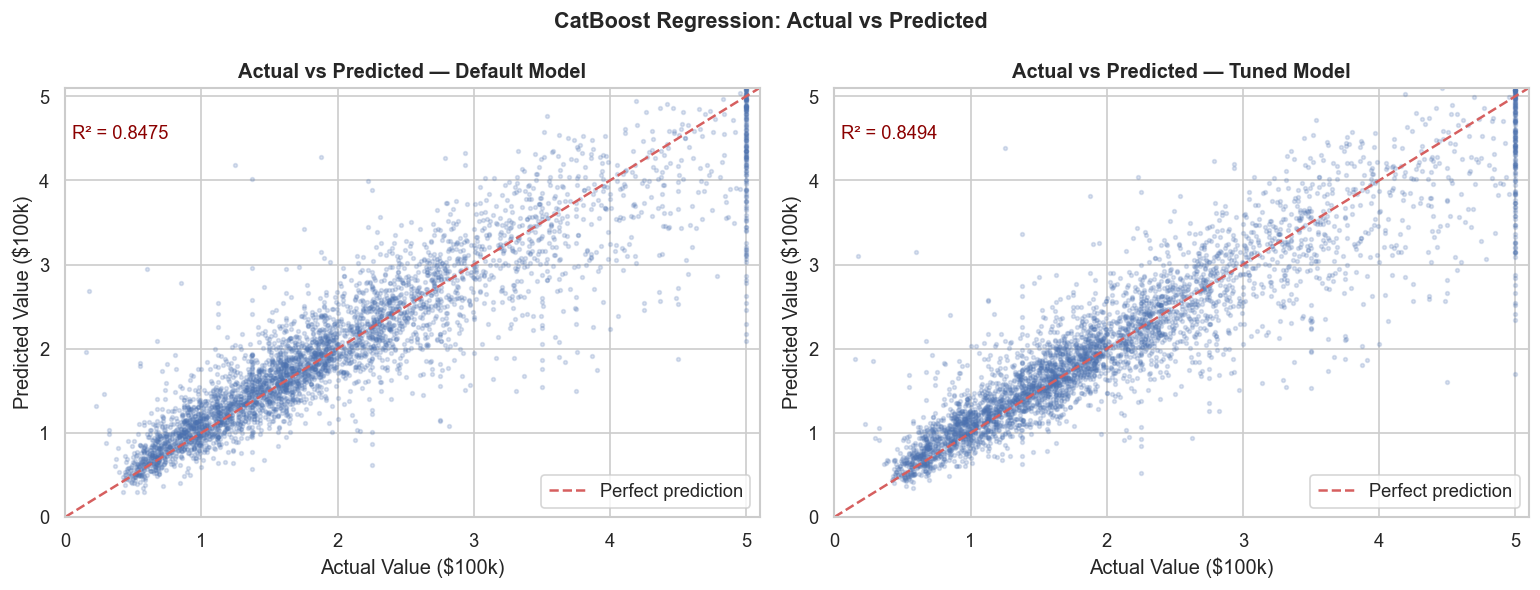


Points near the red diagonal = accurate predictions.
The cluster near y=5.0 shows the census data cap at $500,000 —
the model correctly predicts high values but they are clipped in the data.



In [15]:
# ── Actual vs Predicted ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title in zip(axes,
                               [y_pred_reg_def, y_pred_reg_tuned],
                               ["Default Model", "Tuned Model"]):
    ax.scatter(y_test_r, y_pred, alpha=0.2, s=5, color="#4C72B0")
    lim = [0, df_reg["MedHouseVal"].max() + 0.1]
    ax.plot(lim, lim, "r--", lw=1.5, label="Perfect prediction")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Actual Value ($100k)")
    ax.set_ylabel("Predicted Value ($100k)")
    ax.set_title(f"Actual vs Predicted — {title}", fontweight="bold")
    r2 = r2_score(y_test_r, y_pred)
    ax.text(0.05, 4.5, f"R² = {r2:.4f}", fontsize=11, color="darkred")
    ax.legend()

plt.suptitle("CatBoost Regression: Actual vs Predicted", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("""
Points near the red diagonal = accurate predictions.
The cluster near y=5.0 shows the census data cap at $500,000 —
the model correctly predicts high values but they are clipped in the data.
""")

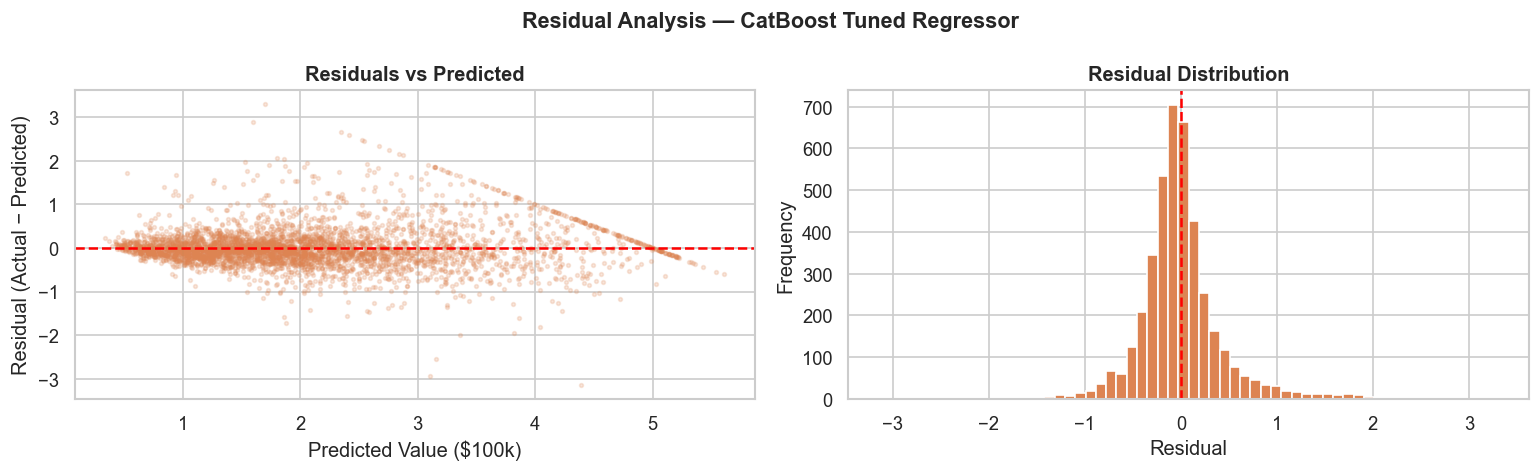


Good residual behaviour:
  - Residuals centred near 0 → model is unbiased on average.
  - Near-normal distribution of residuals → errors are random, not systematic.
  - Some spread at high predicted values → harder to predict luxury homes
    (also the effect of the $500k cap in the dataset).



In [16]:
# ── Residual Plot ────────────────────────────────────────────
residuals = y_test_r.values - y_pred_reg_tuned

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(y_pred_reg_tuned, residuals, alpha=0.2, s=5, color="#DD8452")
axes[0].axhline(0, color="red", linestyle="--", lw=1.5)
axes[0].set_xlabel("Predicted Value ($100k)")
axes[0].set_ylabel("Residual (Actual − Predicted)")
axes[0].set_title("Residuals vs Predicted", fontweight="bold")

axes[1].hist(residuals, bins=60, color="#DD8452", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", lw=1.5)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution", fontweight="bold")

plt.suptitle("Residual Analysis — CatBoost Tuned Regressor", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("""
Good residual behaviour:
  - Residuals centred near 0 → model is unbiased on average.
  - Near-normal distribution of residuals → errors are random, not systematic.
  - Some spread at high predicted values → harder to predict luxury homes
    (also the effect of the $500k cap in the dataset).
""")


# ============================================================
# SECTION 6 — Feature Importance (Regression)
# ============================================================

## 6. Limitations of CatBoost

- Training time and memory usage can increase with larger datasets, deeper trees, or many boosting iterations.
- Hyperparameters still need to be selected carefully.
- A complex boosted ensemble is less directly interpretable than a single decision tree.
- Feature importance shows model reliance, not causation.
- Performance can depend strongly on the dataset and the chosen evaluation metric.
- The California Housing target has a known upper cap, which can make the highest-value observations harder to model accurately.


## 7. Best Use Cases

CatBoost is especially useful when:

1. The data is **tabular / structured**.
2. The dataset contains a mixture of **numeric and categorical** features.
3. Manual categorical preprocessing would otherwise be inconvenient.
4. The task is classification, regression, or ranking.
5. A tree-ensemble model is appropriate and nonlinear relationships are expected.

### For this notebook
California Housing is a good regression example because the target is continuous and the relationships between income, location, occupancy, rooms, and house value are nonlinear.


## 8. Comparison — CatBoost vs Similar Tree-Based Models

We compare CatBoost with:

- **Random Forest** — bagging-based tree ensemble.
- **XGBoost** — gradient-boosted trees.
- **LightGBM** — gradient-boosted trees designed for efficient large-scale training.

### Fair comparison rule
All models use the **same California Housing train/test split** and are evaluated with the same regression metrics:

- MAE
- MSE
- RMSE
- R²

For this dataset, all input variables are numeric, so no categorical encoding is needed for any of the four models.


In [ ]:
# ── Member 3: Model Comparison ───────────────────────────────
# The same train/test split created earlier is reused for every model.

comparison_models = {
    "CatBoost": model_reg_tuned,
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_features=0.8
    )
}

if XGBOOST_AVAILABLE:
    comparison_models["XGBoost"] = XGBRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

if LIGHTGBM_AVAILABLE:
    comparison_models["LightGBM"] = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    )

comparison_rows = []

for name, model in comparison_models.items():
    if name == "CatBoost":
        pred = y_pred_reg_tuned
    else:
        model.fit(X_train_r, y_train_r)
        pred = model.predict(X_test_r)

    comparison_rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_r, pred),
        "MSE": mean_squared_error(y_test_r, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_r, pred)),
        "R²": r2_score(y_test_r, pred)
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("RMSE").reset_index(drop=True)

print("=== Model Comparison on California Housing ===")
display(comparison_df.round(4))

# Lower is better for MAE/MSE/RMSE; higher is better for R².
best_rmse_model = comparison_df.loc[comparison_df["RMSE"].idxmin(), "Model"]
best_r2_model = comparison_df.loc[comparison_df["R²"].idxmax(), "Model"]

print(f"Lowest RMSE in this experiment: {best_rmse_model}")
print(f"Highest R² in this experiment: {best_r2_model}")
print("\nThese are dataset-specific experimental results, not universal rankings.")


In [ ]:
# ── Comparison visualization ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(comparison_df["Model"], comparison_df["RMSE"])
axes[0].set_title("RMSE Comparison")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(comparison_df["Model"], comparison_df["R²"])
axes[1].set_title("R² Comparison")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=20)

plt.suptitle("CatBoost vs Other Tree-Based Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### How to interpret the comparison

- **Lower RMSE** means the model makes smaller typical prediction errors and penalizes large errors more strongly.
- **Higher R²** means the model explains a larger proportion of variation in the target.
- The model with the best metric in this notebook is only the best **for this California Housing experiment and these settings**. It should not be presented as universally superior.


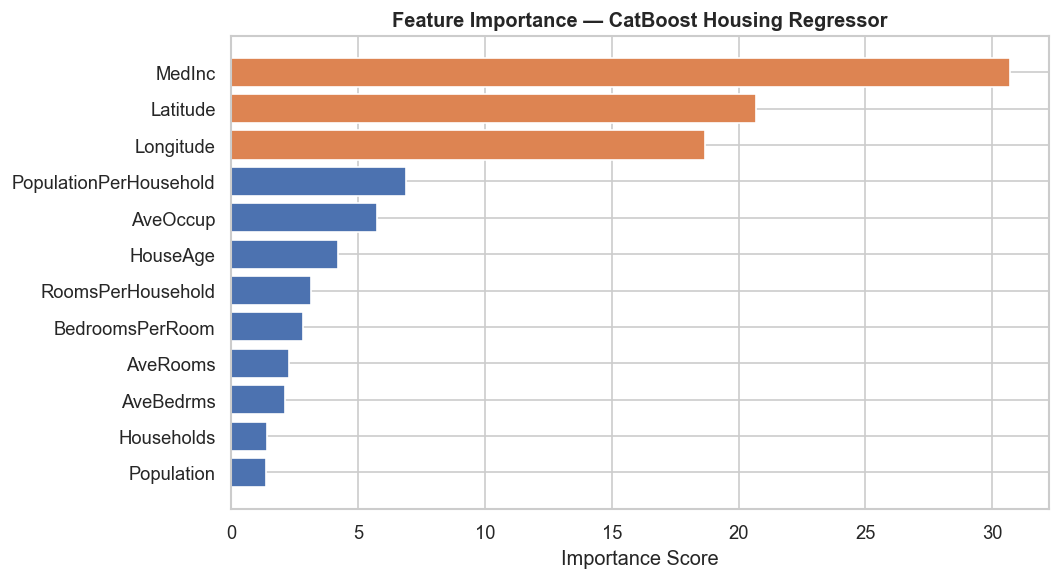

Feature Importance Ranking:
               Feature  Importance
                MedInc   30.701867
              Latitude   20.682418
             Longitude   18.665385
PopulationPerHousehold    6.892352
              AveOccup    5.722374
              HouseAge    4.219728
     RoomsPerHousehold    3.135967
       BedroomsPerRoom    2.830930
              AveRooms    2.279764
             AveBedrms    2.093030
            Households    1.399685
            Population    1.376501

Interpretation:
  - MedInc (Median Income): The dominant feature — wealthier areas have
    higher house values. This aligns with economic intuition.
  - Latitude / Longitude: Geography is crucial — coastal California
    locations (Bay Area, LA) carry a strong price premium.
  - AveOccup (Average Occupancy): Overcrowded housing is often cheaper.
  - Engineered features (RoomsPerHousehold, etc.) add modest signal.

  The top 3 features alone likely explain most of the model's predictive
  power, confirming that

In [17]:
# ============================================================
# SECTION 9 — Feature Importance (Member 4)
# ============================================================

importance_reg = pd.DataFrame({
    "Feature": X_train_r.columns,
    "Importance": model_reg_tuned.get_feature_importance()
}).sort_values("Importance", ascending=False)

display(importance_reg)

plt.figure(figsize=(9, 6))
plt.barh(
    importance_reg["Feature"][::-1],
    importance_reg["Importance"][::-1]
)
plt.xlabel("CatBoost Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance — Tuned CatBoost Housing Regressor",
          fontweight="bold")
plt.tight_layout()
plt.show()

print("Feature Importance Ranking:")
print(importance_reg.to_string(index=False))

print("""
Interpretation:
- A larger importance score means the feature had greater influence on the
  trained CatBoost model's predictions.
- Importance is useful for understanding the model and identifying influential
  variables.
- Importance does NOT prove that a feature causes the target.
- The ranking should be interpreted together with the dataset and the model
  configuration.
""")


## 9.1 SHAP — Optional Advanced Interpretation

SHAP can explain how individual features contribute to individual predictions.

This is useful when we want more than a global feature-importance ranking:
- **Global view:** which features matter overall?
- **Local view:** why was a particular prediction higher or lower?


In [ ]:
# ── SHAP interpretation ─────────────────────────────────────
if SHAP_AVAILABLE:
    explainer = shap.TreeExplainer(model_reg_tuned)
    shap_values = explainer.shap_values(X_test_r)

    shap.summary_plot(
        shap_values,
        X_test_r,
        show=False
    )
    plt.title("SHAP Summary — Tuned CatBoost Regressor")
    plt.tight_layout()
    plt.show()
else:
    print("SHAP is not installed. Run: pip install shap")


### SHAP interpretation

The SHAP summary plot shows both:

- the **importance / magnitude** of a feature's contribution, and
- the **direction** of the contribution for individual observations.

SHAP should be presented as an interpretation method, not as causal proof.


## 10. Practical Tips

### Data preparation
1. Check missing values before training.
2. Identify categorical variables correctly when using CatBoost.
3. Avoid unnecessary scaling for tree-based CatBoost models.
4. Keep feature engineering documented and reproducible.

### Model training
5. Use a validation set or cross-validation for tuning.
6. Monitor overfitting and use early stopping where appropriate.
7. Tune important parameters such as `iterations`, `depth`, `learning_rate`, and `l2_leaf_reg`.
8. Keep the test set separate from tuning decisions.

### Evaluation
9. For regression, report **MAE, MSE, RMSE and R²**.
10. Do not report only a score; explain what the score means.
11. Compare models using the same split and the same metrics.

### Interpretation
12. Use feature importance to understand global model behavior.
13. Use SHAP when individual-prediction explanations are required.
14. Do not interpret feature importance as causation.

### Common mistakes to avoid
- Data leakage between train and test sets.
- Repeatedly tuning on the test set.
- Comparing models on different data splits.
- Using a high R² alone as proof that the model is reliable.
- Claiming that the top feature is the “cause” of the target.


# Final Conclusions

### What we learned
- CatBoost is a gradient-boosting algorithm suitable for structured/tabular regression.
- The California Housing dataset provides a practical continuous-target regression problem.
- Evaluation should use multiple metrics: MAE, MSE, RMSE and R².
- Model comparison is meaningful only when models are evaluated under the same experimental conditions.
- Feature importance helps identify which variables the model relies on most.
- SHAP provides a deeper explanation of individual predictions.

### Strengths observed
- CatBoost provides a straightforward tree-based regression workflow.
- It supports early stopping and built-in feature importance.
- It can also handle categorical features directly, although the California Housing dataset used here is entirely numeric.

### Limitations
- Model performance depends on hyperparameters and the dataset.
- Tree ensembles can require substantial computation as complexity increases.
- Feature importance and SHAP describe model behavior; they do not establish causal relationships.
- The California Housing target has a $500,000 cap, which is a limitation of the data itself.

### Possible improvements
- More systematic hyperparameter optimization.
- Repeated cross-validation.
- Testing additional boosting configurations.
- More extensive SHAP analysis.
- Comparing on a second real-world regression dataset.
